# General Tasks - Group 14

## Task 1: Logistics and Product Development

Importing files [Komponente_K7.csv](data/Logistikverzug/Komponente_K7.csv) and [Logistikverzug_K7.csv](data/Logistikverzug/Logistikverzug_K7.csv) and taking a look at the data


In [25]:
import pandas as pd
from IPython.display import display
from scipy.stats import norm
import warnings; warnings.filterwarnings('ignore')

# Import Data
komponente_k7 = pd.read_csv("data/Logistikverzug/Komponente_K7.csv", sep=";", index_col=0)
logistikverzug_k7 = pd.read_csv("data/Logistikverzug/Logistikverzug_K7.csv", sep=",", index_col=0)

# Display Data
display(komponente_k7.sort_values(by='IDNummer').reset_index(drop=True).head())
display(logistikverzug_k7.sort_values(by='IDNummer').reset_index(drop=True).head())

# Data overview
print("=== Komponente K7 ===")
print(komponente_k7.info())
print(komponente_k7.isnull().sum())

print("\n=== Logistikverzug K7 ===")
print(logistikverzug_k7.info())
print(logistikverzug_k7.isnull().sum())

,IDNummer,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft
0,K7-113-1132-1,2012-11-12,112,1132,0
1,K7-113-1132-10,2012-11-12,112,1132,0
2,K7-113-1132-100,2012-11-13,112,1132,0
3,K7-113-1132-1000,2012-11-22,112,1132,0
4,K7-113-1132-10000,2013-02-15,112,1132,0


,IDNummer,Wareneingang,Herstellernummer,Werksnummer,Fehlerhaft
0,K7-113-1132-1,2012-11-18,112,1132,0
1,K7-113-1132-10,2012-11-19,112,1132,0
2,K7-113-1132-100,2012-11-18,112,1132,0
3,K7-113-1132-1000,2012-11-30,112,1132,0
4,K7-113-1132-10000,2013-02-22,112,1132,0


=== Komponente K7 ===
<class 'pandas.DataFrame'>
RangeIndex: 306490 entries, 1 to 306490
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   IDNummer          306490 non-null  str  
 1   Produktionsdatum  306490 non-null  str  
 2   Herstellernummer  306490 non-null  int64
 3   Werksnummer       306490 non-null  int64
 4   Fehlerhaft        306490 non-null  int64
dtypes: int64(3), str(2)
memory usage: 19.7 MB
None
IDNummer            0
Produktionsdatum    0
Herstellernummer    0
Werksnummer         0
Fehlerhaft          0
dtype: int64

=== Logistikverzug K7 ===
<class 'pandas.DataFrame'>
RangeIndex: 306490 entries, 1 to 306490
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   IDNummer          306490 non-null  str  
 1   Wareneingang      306490 non-null  str  
 2   Herstellernummer  306490 non-null  int64
 3   Werksnummer       306

Both datasets contain 306,490 entries with no missing values. The date columns (`Produktionsdatum`, `Wareneingang`) are stored as strings and need to be converted to `datetime` for further analysis.

In [2]:
# Convert date columns to datetime
komponente_k7['Produktionsdatum'] = pd.to_datetime(komponente_k7['Produktionsdatum'])
logistikverzug_k7['Wareneingang'] = pd.to_datetime(logistikverzug_k7['Wareneingang'])

# Checking if it worked
print(komponente_k7['Produktionsdatum'].dtype)
print(logistikverzug_k7['Wareneingang'].dtype)

datetime64[us]
datetime64[us]


## Task 1a) Distribution of the Logistics Delay
 
Merged both datasets on `IDNummer` and calculated the logistics delay:
`Verzug = Wareneingang − (Produktionsdatum + 1 day)`
 
**Descriptive Statistics:** mean = 6.08, variance = 1.02, var/mean = 0.17, skewness = 0.57, min = 3, max = 14, 306,490 observations.
 
**Interpretation:** The `Verzug` variable is approximately normally distributed with a slight right skew. This conclusion is based on three pieces of evidence:
 
1. The mean, median, and mode are nearly identical (~6: 6.08 / 6 / 6), pointing to symmetry.
2. The dispersion index (variance/mean = 0.17).
3. The histogram visually overlaps with the fitted Normal density curve. Skewness (0.57) and kurtosis (0.63) indicate only a mild right skew.


Shape of Komponente_K7 (306490, 5)
Shape of Merged dataframe (306490, 6)
Count of missing values
 IDNummer            0
Produktionsdatum    0
Herstellernummer    0
Werksnummer         0
Fehlerhaft          0
Wareneingang        0
dtype: int64


count    306490.000000
mean          6.080437
std           1.012302
min           3.000000
25%           5.000000
50%           6.000000
75%           7.000000
max          14.000000
Name: Verzug, dtype: float64

Mean=6.08, Median=6, Mode=6
Variance=1.02, Dispersion Index (Var/Mean)=0.17
Skewness=0.57, Kurtosis=0.63


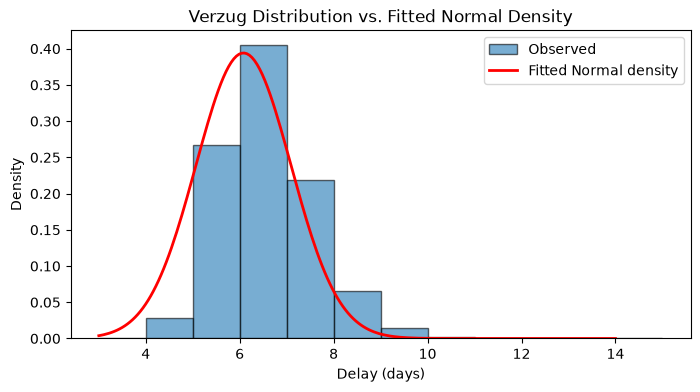

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("Shape of Komponente_K7", komponente_k7.shape)

# Merge DataFrames
logistics_delay = pd.merge(
    komponente_k7[['IDNummer', 'Produktionsdatum', 'Herstellernummer', 'Werksnummer', 'Fehlerhaft']],
    logistikverzug_k7[['IDNummer', 'Wareneingang']],
    on='IDNummer',
    how='inner'
)

# Check if Merge went as expected
print("Shape of Merged dataframe", logistics_delay.shape)
print("Count of missing values\n", logistics_delay.isna().sum())

# Calculating Ausgabedatum and Verzug column needed for later analysis
logistics_delay['Ausgabedatum'] = logistics_delay['Produktionsdatum'] + pd.Timedelta(days=1)
logistics_delay['Verzug'] = (logistics_delay['Wareneingang'] - logistics_delay['Ausgabedatum']).dt.days
logistics_delay['Verzug_AT'] = np.busday_count(logistics_delay['Ausgabedatum'].values.astype('datetime64[D]'), # type: ignore
                                            logistics_delay['Wareneingang'].values.astype('datetime64[D]')) # type: ignore

# Display stats
display(logistics_delay['Verzug'].describe())

mean = logistics_delay["Verzug"].mean()
var = logistics_delay["Verzug"].var()
std = logistics_delay["Verzug"].std()
median = logistics_delay["Verzug"].median()
mode = logistics_delay["Verzug"].mode()[0]

print(f"Mean={mean:.2f}, Median={median:.0f}, Mode={mode:.0f}")
print(f"Variance={var:.2f}, Dispersion Index (Var/Mean)={var/mean:.2f}")
print(f"Skewness={logistics_delay['Verzug'].skew():.2f}, Kurtosis={logistics_delay['Verzug'].kurtosis():.2f}")

# Visual check: histogram vs. fitted Normal density
x = np.linspace(logistics_delay["Verzug"].min(), logistics_delay["Verzug"].max(), 200)

plt.figure(figsize=(8, 4))
plt.hist(
    logistics_delay["Verzug"],
    bins=range(int(logistics_delay["Verzug"].min()), int(logistics_delay["Verzug"].max()) + 2),
    density=True, alpha=0.6, edgecolor='black', label="Observed"
)
plt.plot(x, norm.pdf(x, mean, std), 'r-', lw=2, label="Fitted Normal density")
plt.title("Verzug Distribution vs. Fitted Normal Density")
plt.xlabel("Delay (days)")
plt.ylabel("Density")
plt.legend()
plt.show()


## Goodness-of-Fit Test

To formally test whether the Normal distribution fits the data, we use the **Kolmogorov-Smirnov (KS) test**. This test compares the observed cumulative distribution against a theoretical one.

We chose the KS test over the Shapiro-Wilk test because Shapiro-Wilk has a sample size limit of 5,000, while our dataset contains 306,490 observations. The KS test has no such limitation.

In [4]:
from scipy.stats import binom, kstest

# Test for normal fit
stat, p_value = kstest(logistics_delay["Verzug"], norm(loc=float(mean), scale=float(std)).cdf)
print(f"KS-Test: statistic={stat:.4f}, p-value={p_value:.4e}")

# Test for binomial fit
n_fit = round(float(mean) / (1 - float(var)/float(mean)))
p_fit = float(mean) / n_fit
print(f"Binomial fit: n={n_fit}, p={p_fit:.4f}")

stat_binom, p_binom = kstest(logistics_delay["Verzug"], binom(n=n_fit, p=p_fit).cdf)
print(f"KS-Test (Binomial): statistic={stat_binom:.4f}, p-value={p_binom:.4e}")

KS-Test: statistic=0.2308, p-value=0.0000e+00
Binomial fit: n=7, p=0.8686
KS-Test (Binomial): statistic=0.3327, p-value=0.0000e+00


### Goodness-of-Fit Test Results

We tested three candidate distributions against the observed `Verzug` data:

**1. Poisson**: Ruled out analytically. The Poisson distribution requires variance ≈ mean, but our data shows variance/mean = 0.17 (strongly underdispersed). No statistical test needed.

**2. Normal**: KS test statistic = 0.2308, p-value ≈ 0. The null hypothesis of perfect normality is rejected. However, this is expected: with 306,490 observations, the KS test is sensitive enough to detect even minimal deviations. The visual fit (histogram vs. Normal density curve) and the near-identical mean/median/mode (6.08 / 6 / 6) support that the Normal distribution is a reasonable approximation.

**3. Binomial** (n=7, p=0.87): KS test statistic = 0.3327, p-value ≈ 0. The fit is worse than Normal (higher test statistic = larger deviation from the data).

**Conclusion:** The **Normal distribution** provides the best fit among the tested candidates. While no distribution passes the formal test at this sample size, the Normal approximation is supported by both descriptive statistics and visual evidence.

## Task 1b) Mean Logistics Delay in Working Days

The mean logistics delay in working days is **4.34 days**, compared to **6.08 calendar days** in Task 1a. Excluding weekends reduces the delay by approximately 29%.

**Possible alternatives and limitations:**
- If the warehouse operates on weekends, removing them would understate the actual delay.
- German public holidays are not excluded from the `np.busday_count` calculation, which could matter depending on warehouse operating schedules.
- The assumed `Ausgabedatum = Produktionsdatum + 1 day` can shift weekday dates into weekends and vice versa, slightly affecting the working-day count.
- An alternative approach would be to use a custom business-day calendar (`np.busdaycalendar`) that also excludes public holidays for a more accurate estimate.

In [5]:
mean_at = logistics_delay['Verzug_AT'].mean()
print(f"Mean logistics delay in working days: {mean_at:.2f}")

Mean logistics delay in working days: 4.34


## Task 1c) Visualization with Histogram and Density Function

Two Plotly histograms are shown: one with absolute counts to show the overall volume, and one with probability density to compare against the fitted Normal distribution curve.

**Bin size:** Set to 1 because `Verzug` contains only integer values (whole days). Each bin represents exactly one delay value, giving the clearest view of the discrete distribution without artificially smoothing or grouping the data.

In [6]:
import plotly.express as px
import plotly.graph_objects as go

# Histogram with count
fig = px.histogram(
    logistics_delay, x="Verzug",
    title="Verzug (Anzahl)",
    labels={"Verzug": "Verzug (Kalendertage)"}
)


fig.update_traces(xbins=dict(start=logistics_delay["Verzug"].min(), end=logistics_delay["Verzug"].max(), size=1))
fig.update_layout(title_x=0.5)
fig.show()

# Histogram with probability density and fitted Normal curve
fig = px.histogram(
    logistics_delay, x="Verzug", histnorm="probability density",
    title="Verzug (Dichte)",
    labels={"Verzug": "Verzug (Kalendertage)"}
)
fig.update_traces(xbins=dict(start=logistics_delay["Verzug"].min(), end=logistics_delay["Verzug"].max(), size=1))


x_range = np.linspace(logistics_delay["Verzug"].min(), logistics_delay["Verzug"].max(), 200)
fig.add_trace(go.Scatter(x=x_range, y=norm.pdf(x_range, float(mean), float(std)),
                         mode='lines', name='Normal Density', line=dict(color='red', width=2)))
fig.update_layout(title_x=0.5)
fig.show()


## Task 1d) Decision Tree for Defect Classification

**Goal:** Build a decision tree model to classify whether a component (K7) is defective (`Fehlerhaft`) or not.

**Feature Selection:**
- `Verzug`, `Herstellernummer`, `Werksnummer`, and `Produktionsdatum` (split into `Tag`, `Monat`, `Jahr`)
- `IDNummer` was excluded because it is unique per row and would cause the model to memorize rather than generalize

**Model Setup:**
- `DecisionTreeClassifier` with `max_depth=4` to limit overfitting
- `StratifiedShuffleSplit` (5 folds, 30% test) to ensure the rare defect cases appear in every test set
- Evaluation via confusion matrix, not accuracy (which would be misleading at 99.998% majority class)

**Results:**
- Only 6 out of 306,490 components are faulty (0.002%). This extreme class imbalance means the model has almost no positive examples to learn from.
- On all 5 folds, the model predicted "not faulty" for every row, missing both test defects each time.
- The tree splits primarily on `Tag` (day of month), a feature with no process-related meaning, indicating it is fitting noise.

**Conclusion:** The decision tree method is applicable in principle, but the data does not contain enough defect cases to train a meaningful model. More faulty components would be needed for a validated classifier.

Fehlerhaft
0    306484
1         6
Name: count, dtype: int64

--- Split 0: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 1: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 2: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 3: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]

--- Split 4: 4 defects in train, 2 in test ---
[[91945     0]
 [    2     0]]


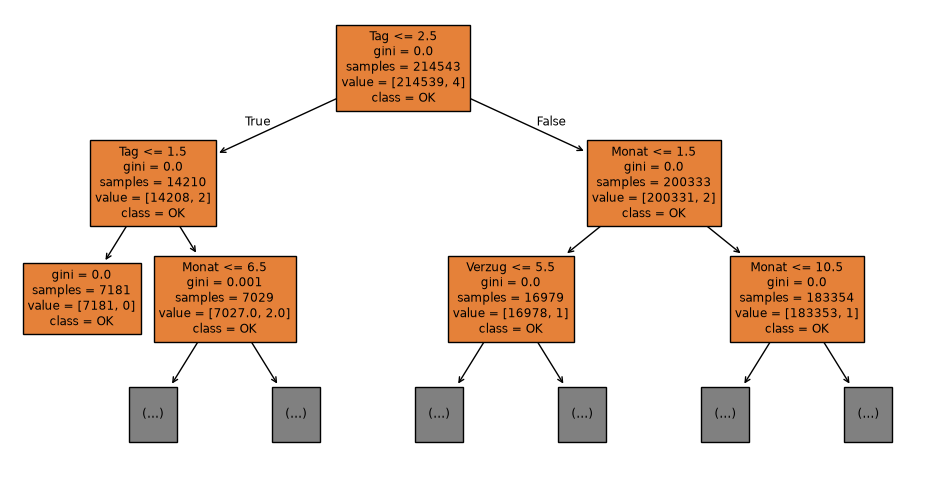

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Analyze amount of faulty components
print(logistics_delay["Fehlerhaft"].value_counts())

# Deriving new columns for day, month, and year from Produktionsdatum
logistics_delay["Tag"]   = logistics_delay["Produktionsdatum"].dt.day
logistics_delay["Monat"] = logistics_delay["Produktionsdatum"].dt.month
logistics_delay["Jahr"]  = logistics_delay["Produktionsdatum"].dt.year

# Splitting the data into features and target variable
X = logistics_delay[["Verzug", "Herstellernummer", "Werksnummer", "Tag", "Monat", "Jahr"]]
y = logistics_delay["Fehlerhaft"]

# Stratified shuffle split: repeated splits, each preserving the class ratio
sss = StratifiedShuffleSplit(n_splits=5, test_size=0.3, random_state=42)

for i, (train_idx, test_idx) in enumerate(sss.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    clf = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n--- Split {i}: {y_train.sum()} defects in train, {y_test.sum()} in test ---")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["OK", "Fehlerhaft"], filled=True, max_depth=2) # type: ignore
plt.show()

## Task 2: Data Storage in Separate Files

**Question:** Explain why it makes sense to store the available data in separate files instead of saving everything in one large table. Name at least four benefits. The available tables represent a typical database structure. What is this structure called?


## 1. You don't store the same thing over and over

Storing separate files instead of one big table is beneficial because you don't store the same thing over and over. This avoids redundancy.

One engine can contain many parts. If everything was in one table, the engine's manufacturer, plant, and production date would be copied on every single part row that belongs to that engine. If the engine is also installed in a vehicle, the vehicle's data gets copied too and stored on every one of those rows. Across the whole dataset, this means the same facts get repeated thousands of times, which increases the storage capacity used.

With separate tables, each piece of information is stored only once. The engine's production date is stored one time, in `Komponente_XX.csv`. Other tables reference it using its ID instead of copying it again, which reuses the same data without duplicating it. This strategy helps save database storage.

## 2. Changes stay correct and avoiding anomalies

Storing data in separate tables is useful because a fact only needs to be changed in one place. If a component's production date is wrong and needs fixing, you fix it once, in the component table. In one big table, the same date could appear on thousands of rows, and you'd have to fix all of them. If you miss even one row, the data now contradicts itself.

This problem has three common versions, and database people give them names:

- **Update anomaly:** a value gets changed in some rows but not others, so the dataset ends up stating two different things about the same data.
- **Insert anomaly:** a new part gets produced but isn't installed in anything yet. In a flat table there's no natural row for it, so it would have to be forced in with missing/fake data.
- **Delete anomaly:** deleting the last row about something also deletes the only proof that thing ever existed.

Separate tables avoid these problems because each fact has one clear place to be stored.

## 3. It's faster and lighter to work with

Separate files are useful because you only load the data you actually need. For a question like "how many parts were registered in Adelshofen," you only need the parts data, the parts lists, and the registration data. You don't need other data like mileage or logistics.

One big table would force every query to load all columns, including the unused ones. Because of the redundancy described above, this table would also be much bigger in size. That means slower loading, more memory used, and a bigger file to work with overall.

## 4. Each table means one thing (modularity)

Separate tables are useful because each one has one clear purpose. There is one table about registrations. There is another table about delivery timing. This makes each table easy to understand on its own.

In one big table, unrelated columns get mixed together, and a single row becomes hard to describe. Separate tables also let different teams manage their own data without affecting other tables' data.

## 5. The links themselves catch errors (referential integrity)

Storing data in separate tables is useful because the links between tables can catch mistakes. If a parts list refers to a part ID, a database can check that this ID actually exists in the parts table. This means you can't install a part that was never produced, or register a vehicle that doesn't exist.

In one big table, there's no such check. Every row stands alone, so a typo in an ID just becomes another wrong row, and nothing catches it. These errors would have to be checked one by one manually, which is very time consuming, and even then errors can still be overlooked.

## What is this structure called?

**A relational database, or normalized relational data model.**

This means the data is split into tables (called relations), each describing one type of entity, and the connections between them are made through shared key columns rather than by physically nesting or duplicating the data.

Each table has a main key that uniquely identifies its rows. In this case, the ID numbers, which are built from part designation, manufacturer, plant, and sequential number. When another table refers to that ID, it is acting as a relational key.

The parts lists are a good example to point at here, because they exist purely to express relationships. A parts list doesn't really describe an entity of its own. It says "this component ID contains this part ID." That is a classic relational join table linking two entities in a many-to-one (or many-to-many) relationship.

*Normalized* is the design principle behind the split: organizing tables so that each piece of data is stored exactly once, and every column depends only on that table's key. That is precisely what produces the benefits described above.

## Task 3: Parts T16 in Registered Vehicles

Determine how many unique parts T16 ended up in vehicles registered in Adelshofen.

**Relevant tables:**
- `Bestandteile_Komponente_K2ST2.csv`: maps `ID_T16` to `ID_K2ST2`
- `Bestandteile_Komponente_K2LE2.csv`: maps `ID_T16` to `ID_K2LE2`
- `Bestandteile_Fahrzeuge_OEM1_Typ11.csv`, `OEM1_Typ12`, `OEM2_Typ21`, `OEM2_Typ22`: map `ID_Sitze` to `ID_Fahrzeug`
- `Zulassungen_alle_Fahrzeuge.csv`: maps `IDNummer` to `Gemeinden`

**Merge pipeline:** T16 parts are linked to seat components (K2ST2 or K2LE2), which are linked to vehicles via `ID_Sitze`, which are then matched to registrations via `ID_Fahrzeug` = `IDNummer`. All four vehicle files must be included.

To identify which component files contain T16 parts, all `Bestandteile_Komponente` files are checked for columns containing "T16".

In [8]:
import pandas as pd
import glob

for file in glob.glob("data/Komponente/Bestandteile_Komponente_*.csv"):
    cols = pd.read_csv(file, sep=";", engine="python", nrows=0).columns
    t16_cols = [c for c in cols if "T16" in c]
    if t16_cols:
        print(f"{file}: {t16_cols}")

data/Komponente\Bestandteile_Komponente_K2LE2.csv: ['ID_T16']
data/Komponente\Bestandteile_Komponente_K2ST2.csv: ['ID_T16']


T16 parts appear in two component files: `K2ST2` and `K2LE2`. Both need to be included in the merge pipeline. Only the required columns are loaded to reduce memory usage.

In [9]:
import pandas as pd

# Load registration table
registration = pd.read_csv(
    "data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv",
    sep=";",
    engine="python",
    usecols=["IDNummer", "Gemeinden"]
)
registration.columns = registration.columns.str.strip()

# Load T16 -> K2ST2 mapping
k2st2 = pd.read_csv(
    "data/Komponente/Bestandteile_Komponente_K2ST2.csv",
    sep=";",
    engine="python",
    usecols=["ID_T16", "ID_K2ST2"]
)

# Load T16 -> K2LE2 mapping
k2le2 = pd.read_csv(
    "data/Komponente/Bestandteile_Komponente_K2LE2.csv",
    sep=";",
    engine="python",
    usecols=["ID_T16", "ID_K2LE2"]
)

Each vehicle file is read in chunks and merged with both component tables (K2ST2, K2LE2) to find T16 parts. The results are then joined with the registration table to get the municipality.

In [10]:
vehicle_files = [
    "data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv",
    "data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv",
    "data/Fahrzeug/Bestandteile_Fahrzeuge_OEM2_Typ21.csv",
    "data/Fahrzeug/Bestandteile_Fahrzeuge_OEM2_Typ22.csv"
]

result_chunks = []

for file in vehicle_files:
    print("Reading:", file)
    for chunk in pd.read_csv(
        file, sep=";", engine="python",
        chunksize=50000, usecols=["ID_Sitze", "ID_Fahrzeug"]
    ):
        # Merge with K2ST2 seat components
        merged_k2st2 = chunk.merge(k2st2, left_on="ID_Sitze", right_on="ID_K2ST2", how="inner")
        merged_k2st2 = merged_k2st2.merge(registration, left_on="ID_Fahrzeug", right_on="IDNummer", how="inner")
        result_chunks.append(merged_k2st2[["ID_T16", "Gemeinden"]])

        # Merge with K2LE2 seat components
        merged_k2le2 = chunk.merge(k2le2, left_on="ID_Sitze", right_on="ID_K2LE2", how="inner")
        merged_k2le2 = merged_k2le2.merge(registration, left_on="ID_Fahrzeug", right_on="IDNummer", how="inner")
        result_chunks.append(merged_k2le2[["ID_T16", "Gemeinden"]])

Reading: data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv
Reading: data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ12.csv
Reading: data/Fahrzeug/Bestandteile_Fahrzeuge_OEM2_Typ21.csv
Reading: data/Fahrzeug/Bestandteile_Fahrzeuge_OEM2_Typ22.csv


The results from all files are combined. Duplicates are removed and the data is filtered for Adelshofen.

In [11]:
# Combine and deduplicate
result = pd.concat(result_chunks, ignore_index=True)
result = result.drop_duplicates()

# Filter for Adelshofen
adelshofen = result[result["Gemeinden"].str.upper() == "ADELSHOFEN"]
count = adelshofen["ID_T16"].nunique()
print("Number of unique T16 parts in Adelshofen:", count)

Number of unique T16 parts in Adelshofen: 48


**Result:** 48 unique T16 parts were found in vehicles registered in Adelshofen.

## Task 4: Attributes of the Registration Table

Identify the data types of all attributes in `Zulassungen_alle_Fahrzeuge.csv` and describe their characteristics.

In [12]:
import pandas as pd

# Import the relevant file
registration = pd.read_csv("data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv", sep=";",)

display(registration.head())
display(registration.info())

,Unnamed: 0,IDNummer,Gemeinden,Zulassung
0,408097,11-1-11-1,DRESDEN,2009-01-01
1,408098,11-1-11-2,DRESDEN,2009-01-01
2,1,12-1-12-1,LEIPZIG,2009-01-01
3,2,12-1-12-2,LEIPZIG,2009-01-01
4,3,12-1-12-3,DORTMUND,2009-01-01


<class 'pandas.DataFrame'>
RangeIndex: 3204104 entries, 0 to 3204103
Data columns (total 4 columns):
 #   Column      Dtype
---  ------      -----
 0   Unnamed: 0  int64
 1   IDNummer    str  
 2   Gemeinden   str  
 3   Zulassung   str  
dtypes: int64(1), str(3)
memory usage: 200.5 MB


None

The registration table `Zulassungen_alle_Fahrzeuge.csv` contains 3,204,104 entries with 4 columns and no missing values.

| Attribute | Pandas dtype | Actual Data Type | Scale Level | Description |
|---|---|---|---|---|
| Unnamed: 0 | int64 | Integer (index) | Discrete | Row index from CSV export, not a meaningful attribute |
| IDNummer | str | String (categorical) | Nominal | Unique vehicle identifier, e.g. `11-1-11-1` |
| Gemeinden | str | String (categorical) | Nominal | Municipality name, e.g. `DRESDEN` |
| Zulassung | str | Date (temporal) | Discrete | Registration date, stored as string, e.g. `2009-01-01` |

**Data Type Characteristics:**

- **Nominal:** Classification and labeling. Values can only be compared for equality (A = B or A ≠ B). No ranking or ordering possible. Examples: `IDNummer`, `Gemeinden`.
- **Ordinal:** Ordered values with ranking (A > B > C), but differences between values are not meaningful. Not present in this table.
- **Discrete:** Finite value range. Values can be counted and compared. `Unnamed: 0` is a row counter, `Zulassung` contains individual calendar dates (finite set of distinct values).
- **Continuous:** Infinite value range with meaningful differences. Not present in this table.

In [13]:
# Convert registration date from string to datetime
registration["Zulassung"] = pd.to_datetime(registration["Zulassung"])
print(registration.dtypes)

Unnamed: 0             int64
IDNummer                 str
Gemeinden                str
Zulassung     datetime64[us]
dtype: object


## Task 5: Linear Model for Mileage

Create a linear regression model from `Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv` to predict the mileage at failure (`Fehlerhaft_Fahrleistung`) based on suitable variables. The dataset contains only vehicles with defects (198,069 entries).

**Feature selection:**
- `days`: vehicle age in days at time of failure
- `fuel`: fuel consumption
- `engine`: engine size (small, medium, large), one-hot encoded with `drop='first'` (reference category: large)

Excluded: `ID_Fahrzeug` (unique identifier), `Herstellernummer` (constant value 1), `Werksnummer` (only 2 values, low predictive value), `Fehlerhaft_Datum` (only known after failure, not a predictor).

Importing and overviewing the data

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Importing the csv-file
data = pd.read_csv('data/Fahrzeug/Fahrzeuge_OEM1_Typ11_Fehleranalyse.csv')

# Data overview
display(data.head())
display(data.info())
print(f"All {len(data)} entries have Fehlerhaft_Fahrleistung > 0")

,Unnamed: 0,X,X1,ID_Fahrzeug,Herstellernummer,Werksnummer,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung,days,fuel,engine
0,9,9,9,11-1-11-9,1,11,2010-03-16,34824.319559,1493.150761,4.003670,small
1,11,11,11,11-1-11-11,1,11,2010-03-16,74217.428309,1044.462231,11.042487,large
2,13,13,13,11-1-11-13,1,11,2010-03-16,32230.699639,749.669810,3.579117,small
3,15,15,15,11-1-11-15,1,11,2010-03-16,44885.783551,858.688003,4.666801,small
4,37,37,37,11-1-11-37,1,11,2010-03-17,86348.329866,1478.204174,4.634381,small


<class 'pandas.DataFrame'>
RangeIndex: 198069 entries, 0 to 198068
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               198069 non-null  int64  
 1   X                        198069 non-null  int64  
 2   X1                       198069 non-null  int64  
 3   ID_Fahrzeug              198069 non-null  str    
 4   Herstellernummer         198069 non-null  int64  
 5   Werksnummer              198069 non-null  int64  
 6   Fehlerhaft_Datum         198069 non-null  str    
 7   Fehlerhaft_Fahrleistung  198069 non-null  float64
 8   days                     198069 non-null  float64
 9   fuel                     198069 non-null  float64
 10  engine                   198069 non-null  str    
dtypes: float64(3), int64(5), str(3)
memory usage: 22.1 MB


None

All 198069 entries have Fehlerhaft_Fahrleistung > 0


The data is split into 70% training and 30% test set using `train_test_split` with a fixed `random_state` for reproducibility.

In [15]:
# defining feature- and targetvector

X = data[['days', 'fuel', 'engine']]

y = data['Fehlerhaft_Fahrleistung']

# Creating a Train-Test-Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

The `engine` column contains categorical values (`small`, `medium`, `large`) and needs to be one-hot encoded. `drop='first'` removes the `large` category as the reference. The encoded columns are then combined with the numeric features `days` and `fuel` into the final feature arrays.

In [16]:
# One Hot Encoding the engine
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoder.fit(x_train[['engine']])

encoded_engine_train = encoder.transform(x_train[['engine']])
encoded_engine_test = encoder.transform(x_test[['engine']])

# Combine numeric features with encoded engine columns
X_train = np.column_stack([x_train['days'].to_numpy(), 
                   x_train['fuel'].to_numpy(), encoded_engine_train]) # type: ignore

X_test = np.column_stack([x_test['days'].to_numpy(), 
                   x_test['fuel'].to_numpy(), encoded_engine_test]) # type: ignore

A `LinearRegression` model from scikit-learn is trained on the encoded feature set. The model is evaluated using 5-fold cross-validation on the training data and then tested on the held-out test set using the R² score.

In [17]:
print("Feature Names:", encoder.get_feature_names_out())

# Train the model
model = LinearRegression()
model.fit(X=X_train, y=y_train)

# Calculate the evaluation scores
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("R² mean: %0.4f (std: %0.4f)" % (scores.mean(), scores.std()))

# Calculate the R² Score
y_pred = model.predict(X_test)
print(f"R² score (test set): {r2_score(y_test, y_pred):.4f}")

Feature Names: ['engine_medium' 'engine_small']
R² mean: 0.4827 (std: 0.0037)
R² score (test set): 0.4862


The model coefficients show the effect of each feature on the predicted mileage at failure. The intercept represents the baseline for a vehicle with a large engine.

In [18]:
feature_names = ['days', 'fuel'] + list(encoder.get_feature_names_out())

# Calculating the coefficients
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_})

print(f"Intercept: {model.intercept_:.2f}")
display(coef_df)

Intercept: 9904.54


,Feature,Coefficient
0,days,-0.175037
1,fuel,5218.744921
2,engine_medium,7749.400361
3,engine_small,11054.006603


The predicted vs. actual scatter plot visualizes the model fit. Points close to the red diagonal indicate accurate predictions.

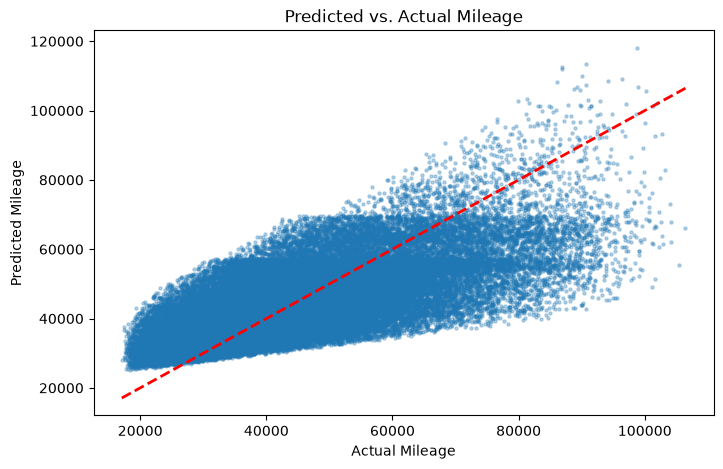

In [19]:
import matplotlib.pyplot as plt

# Predicted vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, s=5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Mileage")
plt.ylabel("Predicted Mileage")
plt.title("Predicted vs. Actual Mileage")
plt.show()

## Model Results

**R² Score:** 0.486 (cross-validation mean: 0.483). The model explains approximately 49% of the variance in mileage at failure. The remaining 51% is influenced by factors not captured in this dataset (e.g. driving behavior, road conditions, maintenance).

**Coefficients:**

| Feature | Coefficient | Interpretation |
|---|---|---|
| Intercept | 9,904.54 | Baseline mileage at failure for a large engine |
| days | -0.18 | Older vehicles tend to fail at slightly lower mileage |
| fuel | 5,218.74 | Higher fuel consumption is associated with significantly higher mileage at failure |
| engine_medium | +7,749.40 | Medium engines fail ~7,750 km later than large engines |
| engine_small | +11,054.01 | Small engines fail ~11,050 km later than large engines |

**Recommendations for OEM1:**
- **Engine size has the strongest effect.** Small engines last significantly longer before failure than large engines (+11,054 km). OEM1 should investigate why large engines fail earlier and whether design or material differences cause this.
- **Fuel consumption** is positively correlated with mileage at failure. Vehicles with higher consumption tend to drive longer before a defect occurs. This could indicate that higher-performance vehicles are built more robustly.
- **Vehicle age** has a negligible effect (-0.18 km per day). Age alone is not a strong predictor of failure mileage.
- **Model limitation:** With R² = 0.49, the model captures only about half the variance. Additional variables (e.g. maintenance history, driving patterns) would be needed for more accurate predictions.

## Task 6: Hit and Run Accident Investigation

On 11.08.2010, there was a hit-and-run accident. The police need to find out where the vehicle with body part number `K5-112-1122-79` was registered.

**Strategy:**
1. Identify which column contains body part IDs by checking a vehicle parts file
2. Search all `Bestandteile_Fahrzeuge` files for the body part number to find the vehicle ID
3. Cross-check the vehicle in the corresponding `Fahrzeuge` file to verify plausibility
4. Look up the vehicle ID in the registration table to find the municipality
5. Retrieve geographic details from the geodata table

Checking the structure of a vehicle parts file to identify the relevant column for body parts.

In [20]:
import pandas as pd

df = pd.read_csv("data/Fahrzeug/Bestandteile_Fahrzeuge_OEM1_Typ11.csv", sep = ";").drop(columns=["Unnamed: 0"])

df.head()

,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug
0,K4-112-1121-3,K3SG1-105-1051-32,K2LE1-109-1091-2,K1BE1-101-1011-7,11-1-11-1
1,K4-112-1121-4,K3SG1-105-1051-141,K2ST1-109-1092-5,K1BE1-101-1011-12,11-1-11-2
2,K4-112-1121-7,K3SG1-105-1051-106,K2ST1-109-1092-57,K1BE1-101-1011-38,11-1-11-3
3,K4-112-1121-9,K3SG1-105-1051-21,K2ST1-109-1092-91,K1BE1-101-1011-97,11-1-11-4
4,K4-112-1121-11,K3SG1-105-1051-59,K2ST1-109-1092-4,K1BE1-101-1011-65,11-1-11-5


The body part IDs are stored in the `ID_Karosserie` column. All four vehicle parts files are searched for the given body part number.

In [21]:
body_part_number = "K5-112-1122-79"

bestandteile_files = ["OEM1_Typ11.csv", "OEM1_Typ12.csv", "OEM2_Typ21.csv", "OEM2_Typ22.csv"]

# Check the already loaded file first
check = df[df["ID_Karosserie"] == body_part_number]

if len(check) == 0:
    for i in bestandteile_files[1:]:
        body_parts = pd.read_csv("data/Fahrzeug/Bestandteile_Fahrzeuge_" + i, sep=";").drop(columns=["Unnamed: 0"])
        check = body_parts[body_parts["ID_Karosserie"] == body_part_number]
        if len(check) > 0:
            break

display(check)

,ID_Karosserie,ID_Schaltung,ID_Sitze,ID_Motor,ID_Fahrzeug
81,K5-112-1122-79,K3SG1-105-1051-129,K2ST1-109-1092-519,K1BE1-104-1041-409,12-1-12-82


The body part was found in `OEM1_Typ12`. The vehicle ID is `12-1-12-82`. To verify, the vehicle is checked in the corresponding `Fahrzeuge_OEM1_Typ12.csv` file.

In [22]:
id_vehicle = check["ID_Fahrzeug"].values[0]

# Cross-check in vehicle file
vehicles = pd.read_csv("data/Fahrzeug/Fahrzeuge_OEM1_Typ12.csv", sep=";").drop(columns=["Unnamed: 0", "X1"])

check_vehicle = vehicles[vehicles["ID_Fahrzeug"] == id_vehicle]
display(check_vehicle)

,ID_Fahrzeug,Produktionsdatum,Herstellernummer,Werksnummer,Fehlerhaft,Fehlerhaft_Datum,Fehlerhaft_Fahrleistung
81,12-1-12-82,2008-11-21,1,12,0,NaN,0


The vehicle was produced on 2008-11-21, before the accident date (2010-08-11). The vehicle ID is looked up in the registration table.

In [23]:
registration = pd.read_csv("data/Zulassungen/Zulassungen_alle_Fahrzeuge.csv", sep=";").drop(columns=["Unnamed: 0"])

find_registration = registration[registration["IDNummer"] == id_vehicle]
display(find_registration)

,IDNummer,Gemeinden,Zulassung
223,12-1-12-82,ASCHERSLEBEN,2009-01-02


The vehicle is registered in ASCHERSLEBEN. The geodata table provides additional location details.

In [24]:
vehicle_registered_in = find_registration["Gemeinden"].values[0]

geodata = pd.read_csv("data/Geodaten/Geodaten_Gemeinden_v1.2_2017-08-22_TrR.csv", sep=";").drop(columns=["Unnamed: 0", "X"])
aschersleben_details = geodata[geodata["Gemeinde"] == vehicle_registered_in]
display(aschersleben_details)

print(f"\nThe vehicle {id_vehicle} with body part {body_part_number} "
      f"is registered in {vehicle_registered_in}")

,Postleitzahl,Gemeinde,Laengengrad,Breitengrad
393,6449,ASCHERSLEBEN,"11,455041","51,756034"



The vehicle 12-1-12-82 with body part K5-112-1122-79 is registered in ASCHERSLEBEN


**Result:** The vehicle with body part number `K5-112-1122-79` is registered in `ASCHERSLEBEN` (postal code 6449).